<a href="https://colab.research.google.com/github/perarneskjelvik/Selvstudium/blob/main/Funksjon_AND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Funksjon AND

Forfatter: Per Arne Skjelvik

Dato: 19.2.2026

##Formål
Programmet bruker nevrale nettverk for å lære AND-funksjonen.


In [9]:

# importerer nødvendige bibliotek
# !pip install tensorflow

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import Recall, Precision, AUC
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, TensorBoard, EarlyStopping
import random
import matplotlib.pyplot as plt




In [10]:

# Treningsdata AND-funksjon
x_and = []
y_and = []

x_and = [[0,0],[0,1],[1,0],[1,1]]
y_and = [0,0,0,1]


In [ ]:

# Setter seed for random.
# Får da samme beregning av vekter hver gang vi kjører koden.

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


# Definerer lagene/strukturen i modellen

# Nettverket er sekvensielt, dvs hvert lag sender output direkte til neste lag.
model = tf.keras.models.Sequential()

# Definerer input layer som har 2 input
model.add(tf.keras.Input(shape=(2,)))

# Definerer output layer som har kun 1 node/output
# Bruker sigmoid som aktiveringsfunksjon (s-kurve, output alltid mellom 0 og 1)
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

print("Oppsummering modell:")
print("")
print(model.summary())
print("")
input("Trykk enter for å kompilere, trene og teste modellen")

# Plotter modellen til en *.jpg fil
plot_model(model, to_file='plottfil.jpg', show_shapes=True)

# Kompilerer modellen

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.3),
              loss=keras.losses.MeanSquaredError(),
              metrics=['accuracy', Recall(name='recall'),
                       Precision(name='precision'), AUC(name='auc')])


# Trener modellen
model.fit(np.array(x_and), np.array(y_and), batch_size=4, epochs=500)

In [12]:


# Tester modellen
print("Tester modellen:")
q = model.predict( np.array( [[0,1],[1,1]] )  )
print(q)

# Fasit
print("Fasit:")
print("0")
print("1")



Tester modellen:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[0.02261982]
 [0.97441834]]
Fasit:
0
1


In [13]:
# Henter ut funksjonen fra modellen

weights, bias = model.layers[0].get_weights()

# Skriv ut vekter og bias
print("Vekter (weights):")
print(weights)
print("Bias:")
print(bias)

# Den lærte funksjonen er:
# output = sigmoid(weights[0]*x1 + weights[1]*x2 + bias)


Vekter (weights):
[[7.406014 ]
 [7.3944664]]
Bias:
[-11.160516]


In [14]:
# Formelen for den lærte funksjonen
# Output = sigmoid(weights[0]*Input1 + weights[1]*Input2 + bias)

w1 = weights[0, 0]
w2 = weights[1, 0]
b = bias[0]

print(f"Den lærte funksjonen er: Output = sigmoid({w1:.4f} * Input1 + {w2:.4f} * Input2 + {b:.4f})")


Den lærte funksjonen er: Output = sigmoid(7.4060 * Input1 + 7.3945 * Input2 + -11.1605)


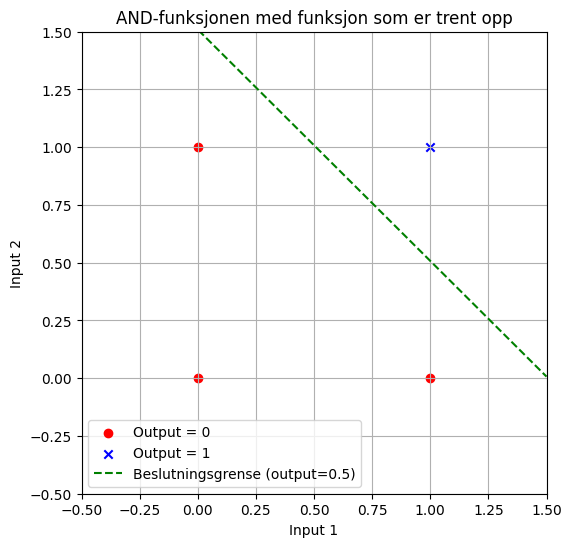

In [15]:
# Plotter funksjonen og treningsdatene

# Konverter treningsdata til numpy-arrays for enklere plotting
x_plot = np.array(x_and)
y_plot = np.array(y_and)

# Plotting av dataene
plt.figure(figsize=(6, 6))

# Plotter punktene for AND-funksjonen
plt.scatter(x_plot[y_plot == 0, 0], x_plot[y_plot == 0, 1], marker='o', color='red', label='Output = 0')
plt.scatter(x_plot[y_plot == 1, 0], x_plot[y_plot == 1, 1], marker='x', color='blue', label='Output = 1')

# Plotter beslutningsgrensen
# w1*x1 + w2*x2 + b = 0
# x2 = (-b - w1*x1) / w2

# Sjekk for å unngå divisjon med null
if weights[1] != 0:
    x1_values = np.linspace(-0.5, 1.5, 100) # Utvid området litt for å se grensen tydelig
    x2_values = (-bias[0] - weights[0, 0] * x1_values) / weights[1, 0]
    plt.plot(x1_values, x2_values, color='green', linestyle='--', label='Beslutningsgrense (output=0.5)')
else:
    # Hvis w2 er 0, er beslutningsgrensen vertikal (x1 = -b/w1)
    if weights[0] != 0:
        plt.axvline(x=-bias[0] / weights[0, 0], color='green', linestyle='--', label='Beslutningsgrense (output=0.5)')

plt.title('AND-funksjonen med funksjon som er trent opp')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True)
plt.legend()
plt.show()
